In [13]:
# Load libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys

%load_ext autoreload
%autoreload 2

# Import load_csv
from helpers import *
from utils import *
from implementations import *
from preprocess import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Dataset shape without using pandas
x_train, x_test, y_train, train_ids, test_ids = load_csv_data('project/data/dataset')

print("Train set shape : ", x_train.shape)
print("Test set shape : ", x_test.shape)
print("test_ids shape : ", test_ids.shape)
print(test_ids)

Train set shape :  (328135, 321)
Test set shape :  (109379, 321)
test_ids shape :  (109379,)
[328135 328136 328137 ... 437511 437512 437513]


In [3]:
print("train_ids shape : ", train_ids.shape)
print(train_ids)
# ça sert à quoi les train_ids et test_ids?

train_ids shape :  (328135,)
[     0      1      2 ... 328132 328133 328134]


## Data cleaning

- IDATE, IMONTH, IYEAR = interview date

- FMONTH = file month

- DISPCODE = 1100: completeted interview , 1200: partial complete interview

- SEQNO = _PSU = annual sequence number

- features containing "HLTH" are insightful

- features containing "fon" "cell" "tel": not useful

In [4]:
# The column names to remove
columns_to_remove = ["IDATE", "IMONTH", "IYEAR", "FMONTH", "SEQNO", "_PSU"]

# Define substrings to check for
substrings_to_remove = ["fon", "cell", "tel"]

for i, col in enumerate(x_train[0]):
     print(i , col)

# Create an array of column indices to remove
#column_indices_to_remove = [i for i, col in enumerate(x_train[0]) if col in columns_to_remove or any(substring in col for substring in substrings_to_remove) ] 

# Remove the specified columns
#data = np.delete(x_train, column_indices_to_remove, axis=1)






0 53.0
1 11.0
2 11162015.0
3 11.0
4 16.0
5 2015.0
6 1100.0
7 2015015629.0
8 2015015629.0
9 nan
10 nan
11 nan
12 nan
13 nan
14 nan
15 nan
16 nan
17 nan
18 1.0
19 1.0
20 2.0
21 1.0
22 nan
23 1.0
24 1.0
25 2.0
26 2.0
27 1.0
28 5.0
29 88.0
30 1.0
31 1.0
32 2.0
33 1.0
34 3.0
35 nan
36 1.0
37 1.0
38 2.0
39 2.0
40 2.0
41 nan
42 2.0
43 2.0
44 2.0
45 2.0
46 1.0
47 2.0
48 3.0
49 nan
50 2.0
51 1.0
52 5.0
53 1.0
54 nan
55 nan
56 nan
57 2.0
58 1.0
59 88.0
60 8.0
61 1.0
62 110.0
63 501.0
64 nan
65 1.0
66 2.0
67 2.0
68 2.0
69 2.0
70 2.0
71 2.0
72 1.0
73 1.0
74 1.0
75 nan
76 3.0
77 888.0
78 nan
79 nan
80 nan
81 555.0
82 205.0
83 304.0
84 303.0
85 308.0
86 205.0
87 1.0
88 64.0
89 102.0
90 30.0
91 98.0
92 220.0
93 30.0
94 105.0
95 nan
96 nan
97 nan
98 nan
99 1.0
100 1.0
101 102015.0
102 8.0
103 2.0
104 2.0
105 nan
106 nan
107 nan
108 nan
109 nan
110 nan
111 nan
112 nan
113 nan
114 nan
115 nan
116 nan
117 nan
118 nan
119 nan
120 nan
121 nan
122 nan
123 nan
124 nan
125 nan
126 nan
127 nan
128 nan
129 nan


## Data processing

In [5]:
# Number of lines that contain NaN values in train set
count_rows_with_nan = np.sum(np.isnan(x_train).any(axis=1))
print("Number of rows containing at least one NaN in train set:", count_rows_with_nan)

# Number of columns that contain NaN values in train set
count_columns_with_nan = np.sum(np.isnan(x_train).any(axis=0))
print("Number of columns containing at least one NaN in train set:", count_columns_with_nan)

# Number of lines that contain NaN values in test set
count_rows_with_nan = np.sum(np.isnan(x_test).any(axis=1))
print("Number of rows containing at least one NaN in test set:", count_rows_with_nan)

# Number of columns that contain NaN values in test set
count_columns_with_nan = np.sum(np.isnan(x_test).any(axis=0))
print("Number of columns containing at least one NaN in test set:", count_columns_with_nan)

Number of rows containing at least one NaN in train set: 328135
Number of columns containing at least one NaN in train set: 239
Number of rows containing at least one NaN in test set: 109379
Number of columns containing at least one NaN in test set: 232


All of the lines both in train set and test set contain at least one Nan. 

In [6]:
def show_NaN_cols(x, x_label):
    """
    Plot the percentage of columns of x that contains a specific percentage of NaN values

    Args:
        x (np.array): input data to analyze  
        x_label: string that describes the dataset x
    """
    
    percentiles = list(range(0, 101, 5))

    # Calculating the percentage of columns with a NaN percentage between x% and (x+5)%
    percentage_columns_with_percentile_nans = [
        (np.isnan(x).sum(axis=0)[
            (np.isnan(x).sum(axis=0) >= x.shape[0]*p/100) &
            (np.isnan(x).sum(axis=0) < x.shape[0]*(p+5)/100)
        ].shape[0] / x.shape[1]) * 100 for p in percentiles[:-1]  # Exclude the last percentile (100%)
    ]

    # Labels for the x-axis
    percentile_labels = [f'{p}-{p+5}%' for p in percentiles[:-1]]

    # Displaying the graph
    plt.figure(figsize=(15, 6))
    plt.bar(percentile_labels, percentage_columns_with_percentile_nans)

    plt.title('Percentage of columns with NaN values in intervals of 5% in the {}'.format(x_label))
    plt.xlabel('Percentage Range of NaN')
    plt.ylabel('Percentage of columns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

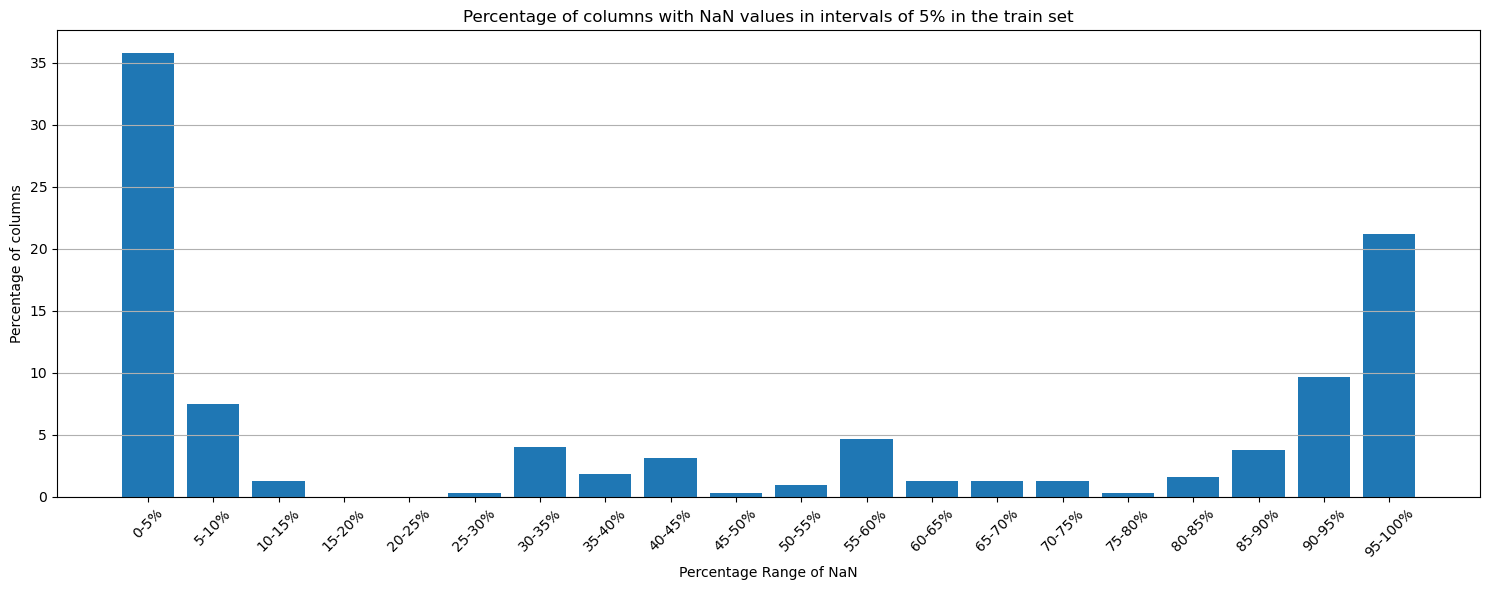

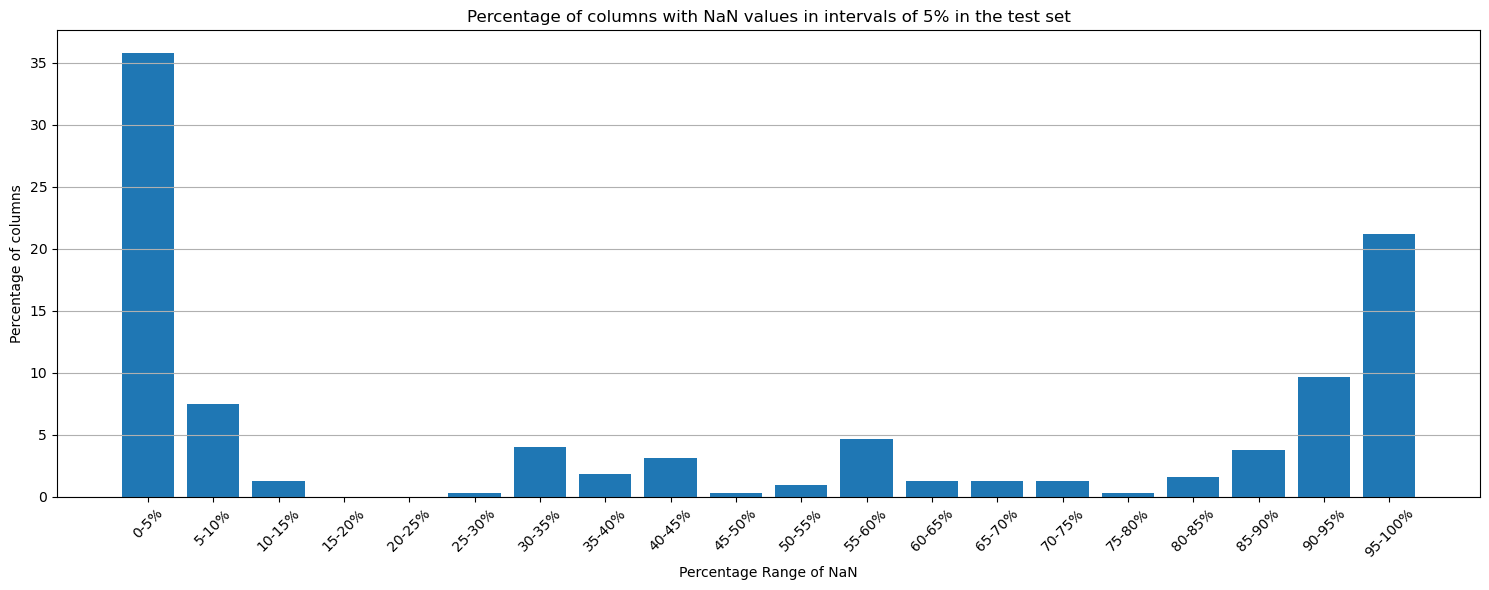

In [7]:
#Analyze the input
show_NaN_cols(x_train, "train set")
show_NaN_cols(x_test, "test set")

# Question: est-ce normal que ce soient exactement les mêmes?

In [8]:
def filter_cols(x, threshold):
    """
    Add the mean of the columns with NaN and return indices of the columns to exclude in the regression including
    those where the standard deviation is equal to 0.
        
    Args:
        x (np.array): data
        threshold (int): % of NaN values that a column of x should contain 
        
    Returns:
        f_x: data with NaN values replaced by zeroes
        rem_cols (np.array): list of indices of columns that contains more than threshold% of NaN values and that
            doesn't contain any 0 standard deviation
    """
    
    f_x = x
    error_matrix = np.isnan(x)
    
    #Identify indices of the columns with more than threshold percentage of NaN values
    nan_ = (np.sum(error_matrix, axis=0) / x.shape[0]) * 100
    rem_cols_NaN = np.where(nan_ > threshold)[0]
    
    #Replace NaN values with the mean of it's columns
    column_means = np.nanmean(f_x, axis=0)
    f_x[error_matrix] = np.take(column_means, np.where(error_matrix)[1])
    
    #Identify columns with 0 standard deviation
    std_x = np.std(f_x, axis=0)
    rem_cols_std = np.where(std_x == 0)[0]
    
    #Final array with indices of the columns to exclude in the classification
    rem_cols = np.unique(np.concatenate((rem_cols_NaN, rem_cols_std)))
    
    return f_x, rem_cols

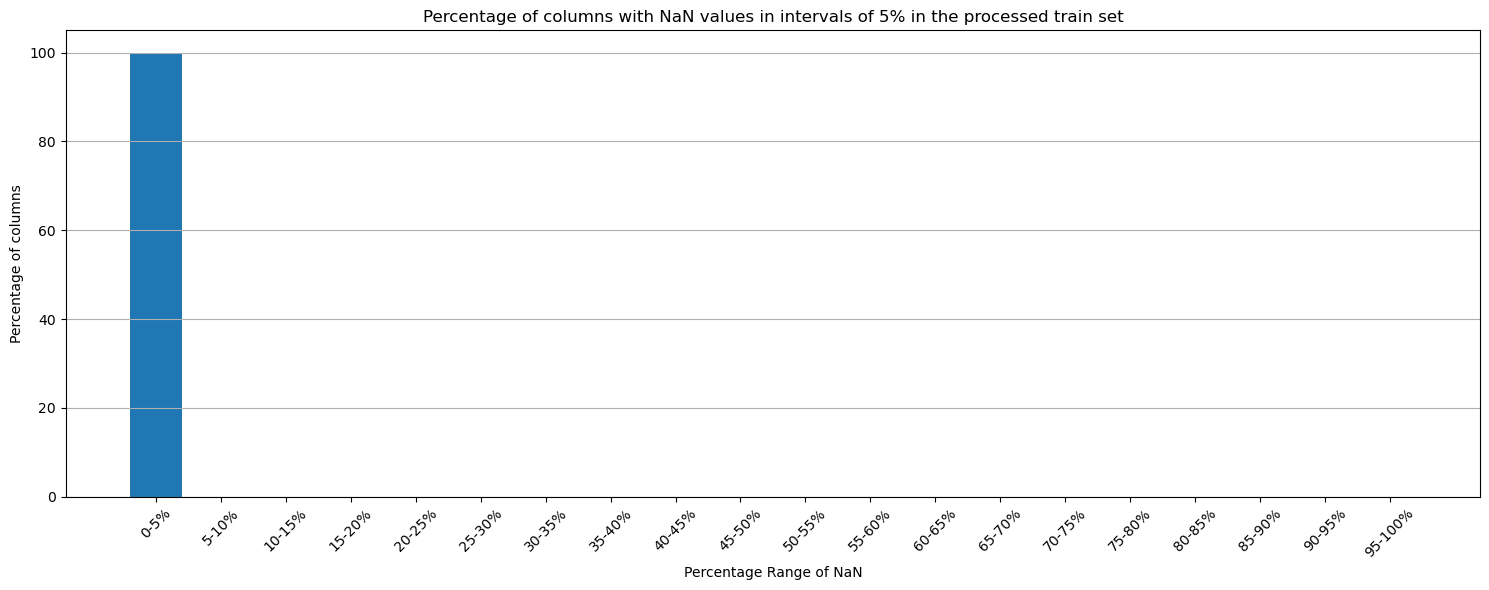

In [9]:
f_x, cols_excluded = filter_cols(x_train,50)
show_NaN_cols(f_x, "processed train set")

In [10]:
def standardize_std(x):
    """
    Standardize the columns of x, might do some other processing after
        
    Args:
        x (np.array): data
        
    Returns:
        s_x: standardized matrix 
    """
    
    s_x = standardize(x)
    
    return s_x

In [11]:
def remove_feature(x, ft):
    """
    Remove features given our model.
    
    Args:
        x (np.array): data
        ft (np.array): indcides of the array of features to remove in x
    Returns:
        f_x: filtered matrix
    """
    

In [14]:
T_x, m_x, std_x = standardize_std(f_x)

In [15]:
# Print the mean and the standard deviation of T_x

print("Mean of T_x : ", np.mean(T_x))
print("Standard deviation of T_x : ", np.std(T_x))

Mean of T_x :  -1.5565368579583865e-16
Standard deviation of T_x :  1.0


In [16]:
# Remove the columns whose index are in cols_excluded

T_x_filtered = np.delete(T_x, cols_excluded, axis=1)

T_x_filtered, m_x_filtered, std_x_filtered = standardize_std(T_x_filtered)

In [17]:
print("Mean of T_x_filtered : ", np.mean(T_x_filtered))
print("Standard deviation of T_x_filtered : ", np.std(T_x_filtered))
print(T_x_filtered.shape)

Mean of T_x_filtered :  -1.0643281624967084e-16
Standard deviation of T_x_filtered :  0.9999999999999992
(328135, 172)


In [ ]:
# export the filtered data to csv
np.savetxt("data/filtered_dataset.csv", T_x_filtered, delimiter=",")

## PCA

In [ ]:
covariance_matrix = np.cov(T_x_filtered, rowvar=False, dtype=np.float64)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [ ]:
# check if the eingenvalues are complex

if np.any(np.iscomplex(eigenvalues)):
    print("Eigenvalues are complex")
else:
    print("Eigenvalues are real")

Eigenvalues are complex


In [ ]:
# Select the number of principal components (e.g., first two)
num_components = 2
selected_eigenvectors = eigenvectors[:, :num_components]


In [ ]:
reduced_data = np.dot(T_x_filtered, selected_eigenvectors)


/Users/yasmine/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


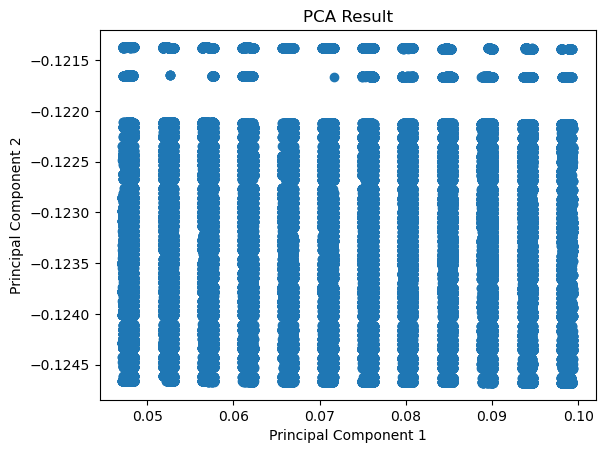

In [ ]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()

/Users/yasmine/anaconda3/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


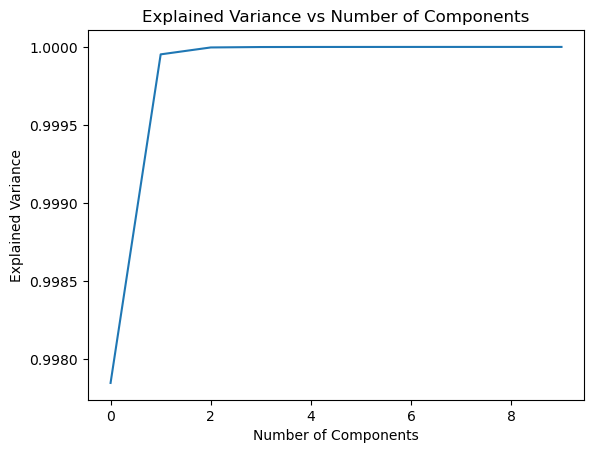

In [ ]:
# Plot explained variance 
plt.plot(np.cumsum(eigenvalues[0:10]) / np.sum(eigenvalues))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.show()


In [ ]:
eigenvalues[0] / np.sum(eigenvalues)


(0.9978456722044404+0j)

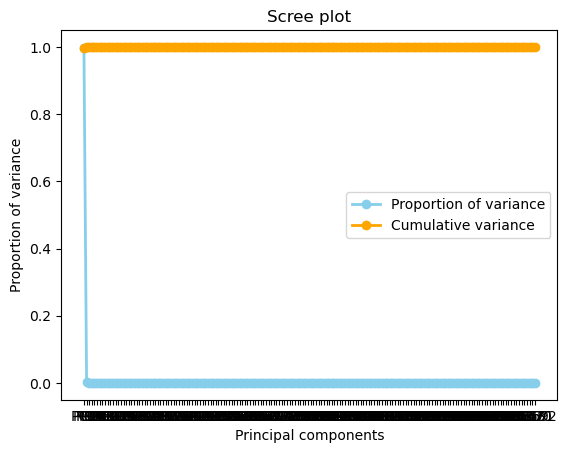

In [ ]:
#1. Calculate the proportion of variance explained by each feature
sum_eigenvalues = np.sum(eigenvalues)

prop_var = [i/sum_eigenvalues for i in eigenvalues]

#2. Calculate the cumulative variance
cum_var = [np.sum(prop_var[:i+1]) for i in range(len(prop_var))]


#3. Plot the results

x_labels = ['PC{}'.format(i+1) for i in range(len(prop_var))]

plt.plot(x_labels, prop_var, marker='o', markersize=6, color='skyblue', linewidth=2, label='Proportion of variance')
plt.plot(x_labels, cum_var, marker='o', color='orange', linewidth=2, label="Cumulative variance")
plt.legend()
plt.title('Scree plot')
plt.xlabel('Principal components')
plt.ylabel('Proportion of variance')
plt.show()

# Visualize outliers


In [28]:
# print the unique values of the first ten component from x_train
for i in range(20,30):
    print(np.unique(f_x[:, i]))

[1.         1.50452609 2.        ]
[1.         1.00575261 2.        ]
[1.]
[1.         1.06692202 2.        ]
[1.         1.63242539 2.         7.         9.        ]
[ 1.          2.          2.43319247  3.          4.          5.
  6.          7.          8.          9.         10.         11.
 12.         13.         14.         15.         18.         20.
 21.         22.         23.         25.         39.         60.
 77.         99.        ]
[1.         2.         2.57200891 3.         4.         5.
 7.         9.        ]
[ 1.          2.          3.          4.          5.          6.
  7.          8.          9.         10.         11.         12.
 13.         14.         15.         16.         17.         18.
 19.         20.         21.         22.         23.         24.
 25.         26.         27.         28.         29.         30.
 60.72481364 77.         88.         99.        ]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22.